Train Precision: 0.8546, Recall: 0.8773, F1-score: 0.8550
Train Confusion Matrix:
[[3758  101]
 [ 446  152]]
Validation Precision: 0.8298, Recall: 0.8664, F1-score: 0.8324
Validation Confusion Matrix:
[[945  21]
 [128  21]]


c:\Users\Kevin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


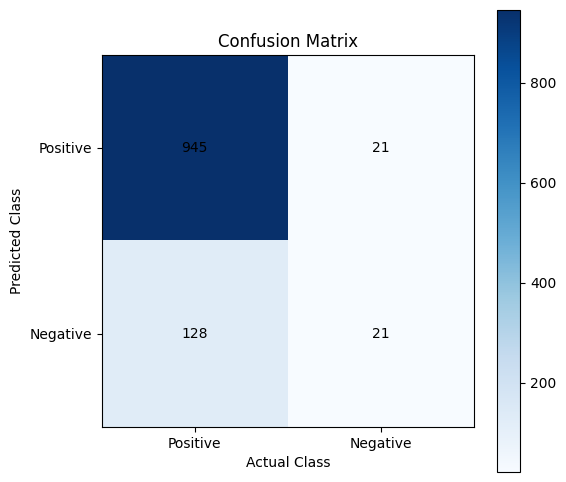

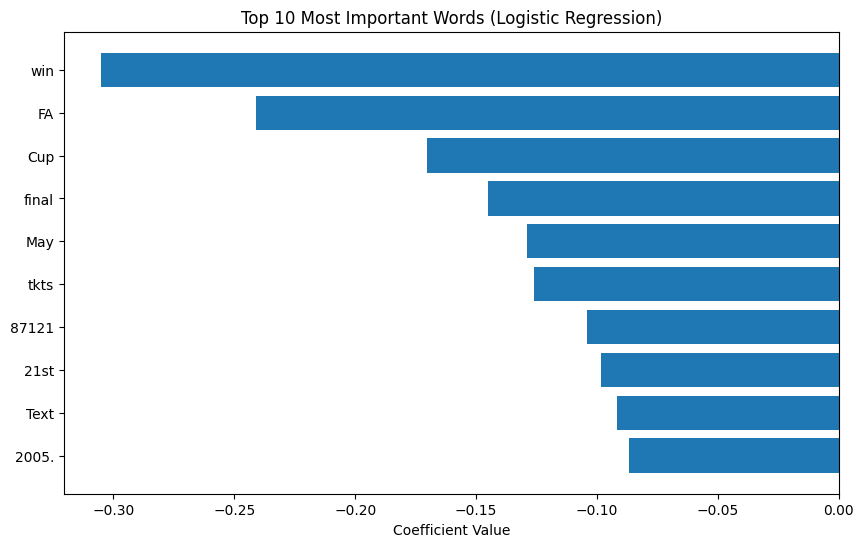

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# 資料路徑
data_path = r"C:\Users\Kevin\Desktop\研究所\ML\Final project\spam.csv"

# 讀取資料
data = pd.read_csv(data_path, encoding="latin-1")  # 指定適當的編碼格式
data = data.rename(columns={"v1": "Category", "v2": "Message"})  # 調整列名稱
data = data[["Category", "Message"]]  # 保留需要的欄位

# 資料前處理
label_encoder = LabelEncoder()
data['category_encoded'] = label_encoder.fit_transform(data['Category'])

X = data['Message']
y = data['category_encoded']

# 分詞和序列化函數
def tokenize_and_pad(texts, vocab_size=10000, max_length=50):
    """簡單的分詞與填充"""
    # 建立字典
    word2idx = {"<PAD>": 0, "<OOV>": 1}
    idx = 2
    for text in texts:
        for word in text.split():
            if word not in word2idx:
                word2idx[word] = idx
                idx += 1
                if len(word2idx) >= vocab_size:
                    break
        if len(word2idx) >= vocab_size:
            break

    # 將文本轉為數字序列
    sequences = []
    for text in texts:
        seq = [word2idx.get(word, word2idx["<OOV>"]) for word in text.split()]
        sequences.append(seq)

    # 填充或截斷序列
    padded_sequences = []
    for seq in sequences:
        if len(seq) > max_length:
            padded_sequences.append(seq[:max_length])
        else:
            padded_sequences.append(seq + [word2idx["<PAD>"]] * (max_length - len(seq)))

    return np.array(padded_sequences), word2idx

# 處理數據
vocab_size = 10000
max_sequence_length = 50
X_pad, word2idx = tokenize_and_pad(X, vocab_size, max_sequence_length)

# 分割數據集
X_train, X_test, y_train, y_test = train_test_split(X_pad, y, test_size=0.2, random_state=42)

# 訓練邏輯迴歸模型
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# 評估模型
def evaluate_model(model, X, y):
    y_pred = model.predict(X)
    precision = precision_score(y, y_pred, average="weighted")
    recall = recall_score(y, y_pred, average="weighted")
    f1 = f1_score(y, y_pred, average="weighted")
    cm = confusion_matrix(y, y_pred)
    return precision, recall, f1, cm

# 訓練集評估
train_precision, train_recall, train_f1, train_cm = evaluate_model(model, X_train, y_train)
print(f"Train Precision: {train_precision:.4f}, Recall: {train_recall:.4f}, F1-score: {train_f1:.4f}")
print(f"Train Confusion Matrix:\n{train_cm}")

# 測試集評估
val_precision, val_recall, val_f1, val_cm = evaluate_model(model, X_test, y_test)
print(f"Validation Precision: {val_precision:.4f}, Recall: {val_recall:.4f}, F1-score: {val_f1:.4f}")
print(f"Validation Confusion Matrix:\n{val_cm}")

# 繪製混淆矩陣圖表
def plot_confusion_matrix(cm, title="Confusion Matrix"):
    plt.figure(figsize=(6, 6))
    plt.imshow(cm, cmap="Blues")
    plt.title(title)
    plt.colorbar()

    classes = ["Positive", "Negative"]
    plt.xticks([0, 1], labels=classes)
    plt.yticks([0, 1], labels=classes)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

    plt.xlabel("Actual Class")
    plt.ylabel("Predicted Class")
    plt.show()

# 繪製測試集的混淆矩陣
plot_confusion_matrix(val_cm, title="Confusion Matrix")

# 繪製模型係數（前 10 個最重要的單字）
feature_names = list(word2idx.keys())
coefficients = model.coef_[0]

# 找出前 10 個最重要的單字
sorted_idx = np.argsort(np.abs(coefficients))[-10:][::-1]
important_words = [feature_names[idx] for idx in sorted_idx]
important_coefficients = coefficients[sorted_idx]

# 可視化前 10 個單字及其分布
plt.figure(figsize=(10, 6))
plt.barh(important_words, important_coefficients)
plt.xlabel("Coefficient Value")
plt.title("Top 10 Most Important Words (Logistic Regression)")
plt.gca().invert_yaxis()
plt.show()


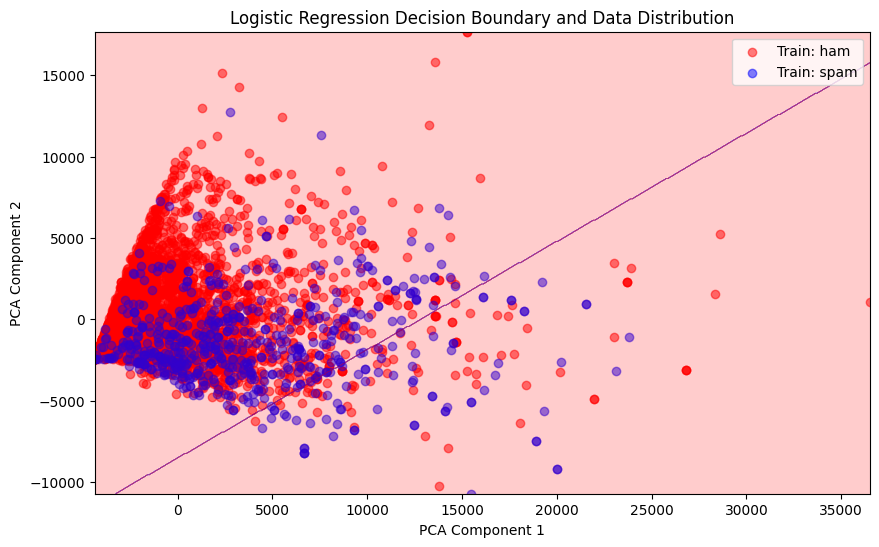

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

# 資料路徑
data_path = r"C:\Users\Kevin\Desktop\研究所\ML\Final project\spam.csv"

# 讀取資料
data = pd.read_csv(data_path, encoding="latin-1")  # 指定適當的編碼格式
data = data.rename(columns={"v1": "Category", "v2": "Message"})  # 調整列名稱
data = data[["Category", "Message"]]  # 保留需要的欄位

# 資料前處理
label_encoder = LabelEncoder()
data['category_encoded'] = label_encoder.fit_transform(data['Category'])

X = data['Message']
y = data['category_encoded']

# 分詞和序列化函數
def tokenize_and_pad(texts, vocab_size=10000, max_length=50):
    """簡單的分詞與填充"""
    # 建立字典
    word2idx = {"<PAD>": 0, "<OOV>": 1}
    idx = 2
    for text in texts:
        for word in text.split():
            if word not in word2idx:
                word2idx[word] = idx
                idx += 1
                if len(word2idx) >= vocab_size:
                    break
        if len(word2idx) >= vocab_size:
            break

    # 將文本轉為數字序列
    sequences = []
    for text in texts:
        seq = [word2idx.get(word, word2idx["<OOV>"]) for word in text.split()]
        sequences.append(seq)

    # 填充或截斷序列
    padded_sequences = []
    for seq in sequences:
        if len(seq) > max_length:
            padded_sequences.append(seq[:max_length])
        else:
            padded_sequences.append(seq + [word2idx["<PAD>"]] * (max_length - len(seq)))

    return np.array(padded_sequences), word2idx

# 處理數據
vocab_size = 10000
max_sequence_length = 50
X_pad, word2idx = tokenize_and_pad(X, vocab_size, max_sequence_length)

# 分割數據集
X_train, X_test, y_train, y_test = train_test_split(X_pad, y, test_size=0.2, random_state=42)

# 使用 PCA 將數據降至 2 維
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# 訓練邏輯迴歸模型
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_pca, y_train)

# 繪製訓練後的分類結果
plt.figure(figsize=(10, 6))
colors = ['red', 'blue']
labels = label_encoder.classes_

# 繪製訓練集結果
for i, label in enumerate(labels):
    plt.scatter(X_train_pca[y_train == i, 0], X_train_pca[y_train == i, 1],
                color=colors[i], label=f'Train: {label}', alpha=0.5)

# 繪製決策邊界
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500), np.linspace(y_min, y_max, 500))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.2, colors=colors)

plt.title('Logistic Regression Decision Boundary and Data Distribution')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.show()


Train Precision: 0.9741, Recall: 0.9737, F1-score: 0.9727
Train Confusion Matrix:
[[3852    7]
 [ 110  488]]
Validation Precision: 0.9719, Recall: 0.9713, F1-score: 0.9699
Validation Confusion Matrix:
[[965   1]
 [ 31 118]]


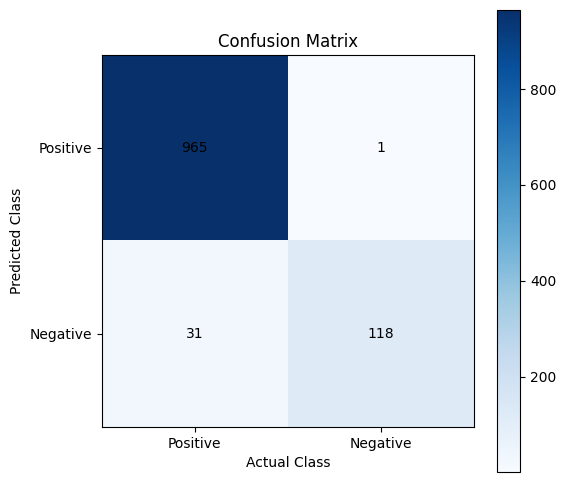

In [3]:
from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Data path
data_path = r"C:\Users\Kevin\Desktop\研究所\ML\Final project\spam.csv"

# Load data
data = pd.read_csv(data_path, encoding="latin-1")  # Adjust encoding as needed
data = data.rename(columns={"v1": "Category", "v2": "Message"})  # Adjust column names
data = data[["Category", "Message"]]  # Retain only required columns

# Preprocessing
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
data['category_encoded'] = label_encoder.fit_transform(data['Category'])

X = data['Message']
y = data['category_encoded']

# Hashing Vectorizer
vectorizer = HashingVectorizer(n_features=10000, alternate_sign=False)  # Adjust n_features as needed
X_hashed = vectorizer.fit_transform(X)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_hashed, y, test_size=0.2, random_state=42)

# Train logistic regression model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Evaluate model
def evaluate_model(model, X, y):
    y_pred = model.predict(X)
    precision = precision_score(y, y_pred, average="weighted")
    recall = recall_score(y, y_pred, average="weighted")
    f1 = f1_score(y, y_pred, average="weighted")
    cm = confusion_matrix(y, y_pred)
    return precision, recall, f1, cm

# Training set evaluation
train_precision, train_recall, train_f1, train_cm = evaluate_model(model, X_train, y_train)
print(f"Train Precision: {train_precision:.4f}, Recall: {train_recall:.4f}, F1-score: {train_f1:.4f}")
print(f"Train Confusion Matrix:\n{train_cm}")

# Test set evaluation
val_precision, val_recall, val_f1, val_cm = evaluate_model(model, X_test, y_test)
print(f"Validation Precision: {val_precision:.4f}, Recall: {val_recall:.4f}, F1-score: {val_f1:.4f}")
print(f"Validation Confusion Matrix:\n{val_cm}")

# Plot confusion matrix
def plot_confusion_matrix(cm, title="Confusion Matrix"):
    plt.figure(figsize=(6, 6))
    plt.imshow(cm, cmap="Blues")
    plt.title(title)
    plt.colorbar()

    classes = ["Positive", "Negative"]
    plt.xticks([0, 1], labels=classes)
    plt.yticks([0, 1], labels=classes)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

    plt.xlabel("Actual Class")
    plt.ylabel("Predicted Class")
    plt.show()

# Plot test set confusion matrix
plot_confusion_matrix(val_cm, title="Confusion Matrix")




Train Precision: 0.9626, Recall: 0.9634, F1-score: 0.9621
Train Confusion Matrix:
[[3836   36]
 [ 127  458]]
Validation Precision: 0.9553, Recall: 0.9561, F1-score: 0.9541
Validation Confusion Matrix:
[[944   9]
 [ 40 122]]


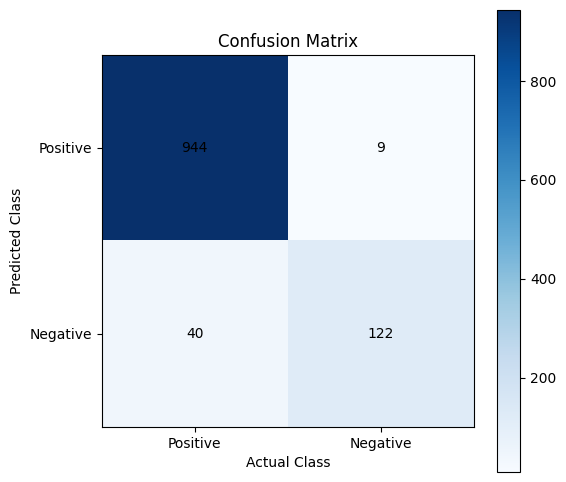

In [4]:
from gensim.models import Word2Vec
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import shuffle
import re

# Data path
data_path = r"C:\Users\Kevin\Desktop\研究所\ML\Final project\spam.csv"

# Load data
data = pd.read_csv(data_path, encoding="latin-1")  # Adjust encoding as needed
data = data.rename(columns={"v1": "Category", "v2": "Message"})  # Adjust column names
data = data[["Category", "Message"]]  # Retain only required columns

# Preprocessing
label_encoder = LabelEncoder()
data['category_encoded'] = label_encoder.fit_transform(data['Category'])

# Text preprocessing: tokenization and cleaning
def preprocess_text(text):
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)  # Remove special characters
    text = text.lower().strip()  # Convert to lowercase
    return text.split()  # Tokenize

data['tokens'] = data['Message'].apply(preprocess_text)

# Shuffle data to ensure random distribution
data = shuffle(data, random_state=42)

# Prepare data for Word2Vec
sentences = data['tokens'].tolist()

# Train Word2Vec model
embed_size = 100  # Embedding vector size
word2vec_model = Word2Vec(sentences, vector_size=embed_size, window=5, min_count=1, workers=4, sg=1)

# Convert text to vector representations using Word2Vec
def vectorize_text(tokens, model, embed_size):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(embed_size)  # Handle empty token lists
    return np.mean(vectors, axis=0)  # Use mean pooling to create fixed-length vector

data['vector'] = data['tokens'].apply(lambda x: vectorize_text(x, word2vec_model, embed_size))

# Split dataset
X = np.stack(data['vector'].values)
y = data['category_encoded']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train logistic regression model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Evaluate model
def evaluate_model(model, X, y):
    y_pred = model.predict(X)
    precision = precision_score(y, y_pred, average="weighted")
    recall = recall_score(y, y_pred, average="weighted")
    f1 = f1_score(y, y_pred, average="weighted")
    cm = confusion_matrix(y, y_pred)
    return precision, recall, f1, cm

# Training set evaluation
train_precision, train_recall, train_f1, train_cm = evaluate_model(model, X_train, y_train)
print(f"Train Precision: {train_precision:.4f}, Recall: {train_recall:.4f}, F1-score: {train_f1:.4f}")
print(f"Train Confusion Matrix:\n{train_cm}")

# Test set evaluation
val_precision, val_recall, val_f1, val_cm = evaluate_model(model, X_test, y_test)
print(f"Validation Precision: {val_precision:.4f}, Recall: {val_recall:.4f}, F1-score: {val_f1:.4f}")
print(f"Validation Confusion Matrix:\n{val_cm}")

# Plot confusion matrix
def plot_confusion_matrix(cm, title="Confusion Matrix"):
    plt.figure(figsize=(6, 6))
    plt.imshow(cm, cmap="Blues")
    plt.title(title)
    plt.colorbar()

    classes = ["Positive", "Negative"]
    plt.xticks([0, 1], labels=classes)
    plt.yticks([0, 1], labels=classes)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

    plt.xlabel("Actual Class")
    plt.ylabel("Predicted Class")
    plt.show()

# Plot test set confusion matrix
plot_confusion_matrix(val_cm, title="Confusion Matrix")


c:\Users\Kevin\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Kevin\AppData\Local\Programs\Python\Python312\Lib\site-packages\transformers\models\bert\modeling_bert.py:440: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:555.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(


Epoch 1/4
Train Loss: 0.0827, Precision: 0.9729, Recall: 0.9733, F1-score: 0.9726
Validation Loss: 0.0386, Precision: 0.9910, Recall: 0.9910, F1-score: 0.9910
Epoch 2/4
Train Loss: 0.0208, Precision: 0.9937, Recall: 0.9937, F1-score: 0.9937
Validation Loss: 0.0244, Precision: 0.9919, Recall: 0.9919, F1-score: 0.9919
Epoch 3/4
Train Loss: 0.0103, Precision: 0.9973, Recall: 0.9973, F1-score: 0.9973
Validation Loss: 0.0674, Precision: 0.9836, Recall: 0.9821, F1-score: 0.9824
Epoch 4/4
Train Loss: 0.0029, Precision: 0.9993, Recall: 0.9993, F1-score: 0.9993
Validation Loss: 0.0431, Precision: 0.9911, Recall: 0.9910, F1-score: 0.9911


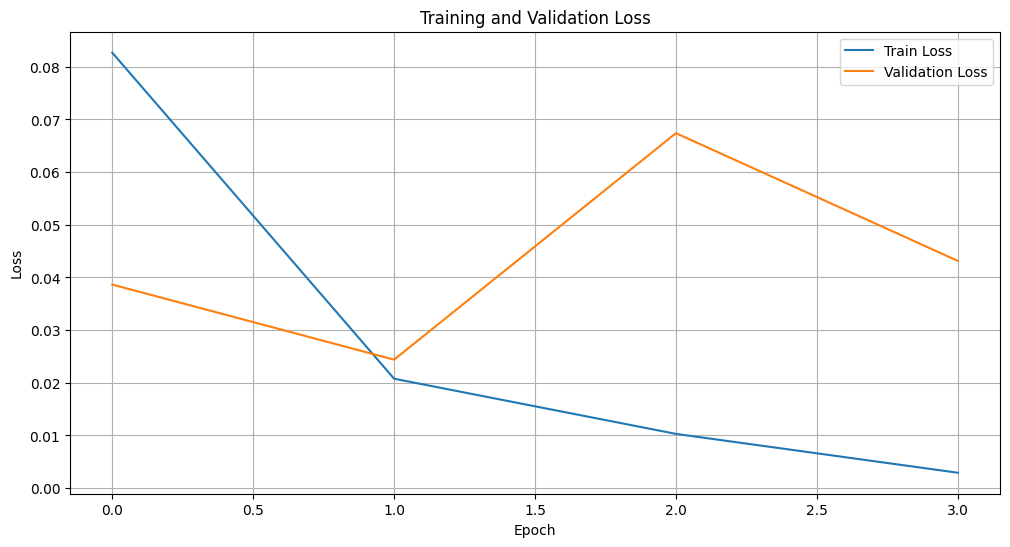

In [5]:
from transformers import BertTokenizer, BertModel
from torch.utils.data import DataLoader, Dataset
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Data path
data_path = r"C:\Users\Kevin\Desktop\研究所\ML\Final project\spam.csv"

# Load data
data = pd.read_csv(data_path, encoding="latin-1")
data = data.rename(columns={"v1": "Category", "v2": "Message"})
data = data[["Category", "Message"]]

# Preprocessing
label_encoder = LabelEncoder()
data['category_encoded'] = label_encoder.fit_transform(data['Category'])

X = data['Message'].values
y = data['category_encoded'].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Dataset class
class SpamDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(label, dtype=torch.long)
        }

# Hyperparameters
MAX_LEN = 128
BATCH_SIZE = 16
LEARNING_RATE = 2e-5
EPOCHS = 4

# Datasets and DataLoaders
train_dataset = SpamDataset(X_train, y_train, tokenizer, MAX_LEN)
test_dataset = SpamDataset(X_test, y_test, tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# BERT-based model
class BERTClassifier(nn.Module):
    def __init__(self, bert_model, num_classes):
        super(BERTClassifier, self).__init__()
        self.bert = bert_model
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(bert_model.config.hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.pooler_output
        pooled_output = self.dropout(pooled_output)
        logits = self.fc(pooled_output)
        return logits

# Load pre-trained BERT model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
bert_model = BertModel.from_pretrained('bert-base-uncased')
model = BERTClassifier(bert_model, num_classes=2).to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

# Training function
def train_model(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    y_true, y_pred = [], []

    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, preds = torch.max(outputs, dim=1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

    precision = precision_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")
    f1 = f1_score(y_true, y_pred, average="weighted")
    return total_loss / len(loader), precision, recall, f1

# Evaluation function
def evaluate_model(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    y_true, y_pred = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, preds = torch.max(outputs, dim=1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    precision = precision_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")
    f1 = f1_score(y_true, y_pred, average="weighted")
    return total_loss / len(loader), precision, recall, f1

# Training loop
train_losses, val_losses = [], []
for epoch in range(EPOCHS):
    train_loss, train_precision, train_recall, train_f1 = train_model(model, train_loader, criterion, optimizer, device)
    val_loss, val_precision, val_recall, val_f1 = evaluate_model(model, test_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch + 1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f}, Precision: {train_precision:.4f}, Recall: {train_recall:.4f}, F1-score: {train_f1:.4f}")
    print(f"Validation Loss: {val_loss:.4f}, Precision: {val_precision:.4f}, Recall: {val_recall:.4f}, F1-score: {val_f1:.4f}")

# Plotting results
plt.figure(figsize=(12, 6))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()
plt.show()
